In [5]:
from simsopt.mhd import Boozer,Vmec
from simsopt.geo import Surface,SurfaceRZFourier

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import neo
from neo import NeoContext,neo_surfaces_from_simsopt_boozer
import time
import numpy as np
from pathlib import Path


mgrid_candidates = [
    Path("tests/test_file/mgrid_c09r00.nc"),
    Path("test_file/mgrid_c09r00.nc"),
]
mgrid_path = next((p for p in mgrid_candidates if p.exists()), None)
if mgrid_path is None:
    raise FileNotFoundError(
        "Cannot find mgrid file. Tried: " + ", ".join(str(p) for p in mgrid_candidates)
    )


initial_rz = (1.57,0)
mgrid_filename = str(mgrid_path)
extcur = None
vmec_path = "/home/zkg/ripplepy/tests/test_file/wout_ncsx_c09r00_free.nc"
# initial_rz = (1.26,0)
# mgrid_filename = '/home/zkg/CN_H1_scan_fieldlines/H1_design/coils/mgrid_h1_design.nc'
# extcur = [50000, 5000, 1, -80000, -40000]
# vmec_path = "/home/zkg/ripplepy/tests/test_file/wout_h1_design.nc"





sur_idx = np.linspace(0.1, 0.5, 10)

RZ_points = []  # 每个元素是 [R, phi, Z]
for s in sur_idx:
    surface = SurfaceRZFourier.from_wout(vmec_path, s)
    RphiZ = surface.cross_section(phi=0)[0]
    RZ = RphiZ[[0, 2]]   # shape: (Npts, 3)
    RZ_points.append(RZ)             # 第一个点: (3,)

RZ_points = np.asarray(RZ_points)       # shape: (len(sur_idx), 3) [R1,Z1], ...]

vmec = Vmec(str(vmec_path))
boozer = Boozer(vmec)
boozer.mpol = 72
boozer.ntor = 36
# ns_list =  np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])
# boozer.register(ns_list/100)
boozer.register(np.linspace(0.1, 1.0, 10))
boozer.bx.verbose =True
boozer.run()

neoclass = neo.from_simsopt_boozer(boozer)
ctx = NeoContext()
ctx.set_boozer(neoclass)
surfaces = neo_surfaces_from_simsopt_boozer(boozer)
print('Surfaces from simsopt Boozer:', surfaces)
ctx.set_flux_surfaces(surfaces.tolist())
ctx.set_resolution(theta_n=200, phi_n=200)
ctx.set_mode_limits(max_m_mode=0, max_n_mode=0)
ctx.set_transport_options(
    npart=50,
    multra=1,
    acc_req=0.01,
    no_bins=100,
    nstep_per=50,
    nstep_min=500,
    nstep_max=5000,
    calc_nstep_max=0,
)
ctx.set_switches(ref_swi=2, eout_swi=2, calc_cur=0)
ctx.set_output_options(
    write_progress=0,
    write_output_files=0,
    write_integrate=0,
    write_diagnostic=0,
    suppress_file_io=True,
)

ctx.setup_grids()
ctx.run_all()

got_surfaces = ctx.surface_map()
got_epstot = ctx.epstot_profile()



# Test importing the MGrid module
# %reset -f
import numpy as np
from ripplepy import MGrid

# from ripplepy.effective_ripple import Effective_Ripple
from ripplepy import set_extcur, initialize_mgrid_field,set_trace_parameters,compute_epstot,find_axis
import time
from func_timeout import func_timeout, FunctionTimedOut
from pathlib import Path

full_torus = False
nfp = 3

mgrid_candidates = [
    Path("tests/test_file/mgrid_c09r00.nc"),
    Path("test_file/mgrid_c09r00.nc"),
]
mgrid_path = next((p for p in mgrid_candidates if p.exists()), None)
if mgrid_path is None:
    raise FileNotFoundError(
        "Cannot find mgrid file. Tried: " + ", ".join(str(p) for p in mgrid_candidates)
    )

mgrid_filename = str(mgrid_path)
# extcur = [6.52271941985300E+05, 6.51868569367400E+05, 5.37743588647300E+05, 2.50000000000000E-07, 2.50000000000000E-07, 2.80949750000000E+04, -5.48049500000000E+04, 3.01228950000000E+04, 9.42409100000000E+04, 4.55138737653200E+04]
# extcur = np.ones(10)
extcur = None


# mgrid_filename = '/home/zkg/CN_H1_scan_fieldlines/H1_design/coils/mgrid_h1_design.nc'
# extcur = [50000, 5000, 1, -80000, -40000]
# initial_rz = (1.26,0)

nturn = 200
nphi = 360
initialize_mgrid_field(mgrid_filename, nfp,full_torus=full_torus)

extcur=set_extcur(extcur)
# sum_bfield_internal = True

axis_rz, R0, axis_fieldline, trace_error_flag = find_axis(initial_rz, timeout=10.0, xtol=1e-5, max_iter=100)
print(f"✓ Magnetic axis found at R={axis_rz[0]:.10f}, Z={axis_rz[1]:.10f}, R0={R0:.10f}")

# initial_gradpsi = compute_initial_gradpsi(extcur,initial_rz[0], initial_rz[1], phi0=0.0,verbose=False)
initial_gradpsi = [1,0,0]
initial_gradpsi = np.array(initial_gradpsi, dtype=np.float64, order='F')
set_trace_parameters(nturn, nphi)
ripplepy_results = []
for i in RZ_points:

    fieldline_data = np.zeros((nturn*nphi, 20), dtype=np.float64, order='F')
    geocur = np.zeros((nturn*nphi, 3), dtype=np.float64, order='F')
    R0 = np.array(R0, dtype=np.float64, order='F')
    Bboundary = np.array(0.0, dtype=np.float64, order='F')
    initial_rz = np.array(i, dtype=np.float64, order='F')
    # # 预分配轨线数据缓冲区并传入 Fortran 例程（Fortran 连续）

    starttime = time.time()
    epsilon_eff, Bboundary = compute_epstot(R0,extcur, initial_rz, initial_gradpsi, fieldline_data)
    epsilon_eff = epsilon_eff*R0**2
    endtime = time.time()
    time_elapsed = endtime - starttime
    print(f"✓ Ripple fieldline computed @ {initial_rz[0]:.10f}, {initial_rz[1]:.10f}. epsilon_eff={epsilon_eff:.6e}, Bboundary={Bboundary:.6e},time={time_elapsed:.3f} s")
    ripplepy_results.append(( epsilon_eff))

print("ripplepy_results:", ripplepy_results)
ripplepy_200nturn_results = ripplepy_results

nturn = 400
set_trace_parameters(nturn, nphi)
ripplepy_results = []
for i in RZ_points:

    fieldline_data = np.zeros((nturn*nphi, 20), dtype=np.float64, order='F')
    geocur = np.zeros((nturn*nphi, 3), dtype=np.float64, order='F')
    R0 = np.array(R0, dtype=np.float64, order='F')
    Bboundary = np.array(0.0, dtype=np.float64, order='F')
    initial_rz = np.array(i, dtype=np.float64, order='F')
    # # 预分配轨线数据缓冲区并传入 Fortran 例程（Fortran 连续）

    starttime = time.time()
    epsilon_eff, Bboundary = compute_epstot(R0,extcur, initial_rz, initial_gradpsi, fieldline_data)
    epsilon_eff = epsilon_eff*R0**2
    endtime = time.time()
    time_elapsed = endtime - starttime
    print(f"✓ Ripple fieldline computed @ {initial_rz[0]:.10f}, {initial_rz[1]:.10f}. epsilon_eff={epsilon_eff:.6e}, Bboundary={Bboundary:.6e},time={time_elapsed:.3f} s")
    ripplepy_results.append(( epsilon_eff))

print("ripplepy_results:", ripplepy_results)
ripplepy_400nturn_results = ripplepy_results

Read ns=99, mpol=11, ntor=6, mnmax=137, mnmax_nyq=537
compute_surfs (0-based indices):  9 19 29 39 48 58 68 78 88 97
Initializing with mboz=72, nboz=36
ntheta = 290, nzeta = 146, # threads = 12
                   |        outboard (theta=0)      |      inboard (theta=pi)      |
thread js_b js zeta| |B|input  |B|Boozer    Error   | |B|input  |B|Boozer    Error |
------------------------------------------------------------------------------------
   8     8  88   0  1.484e+00  1.484e+00  2.830e-07  1.896e+00  1.896e+00  1.816e-07
                pi  1.460e+00  1.460e+00  3.616e-08  1.716e+00  1.716e+00  9.439e-08
   9     9  97   0  1.466e+00  1.466e+00  3.597e-08  1.876e+00  1.876e+00  3.243e-07
                pi  1.449e+00  1.449e+00  1.119e-07  1.754e+00  1.754e+00  2.333e-06
   0     0   9   0  1.603e+00  1.603e+00  7.509e-12  1.716e+00  1.716e+00  1.700e-10
                pi  1.568e+00  1.568e+00  1.784e-14  1.633e+00  1.633e+00  1.875e-12
   3     3  39   0  1.549e+00  1.549e+00 

pyneo: [0.00014628 0.00021859 0.0003387  0.00053658 0.00075862 0.00105665
 0.00142971 0.00192698 0.00289984 0.00506059]
ripplepy_200nturn: [0.00048997 0.00057114 0.0007443  0.00071758 0.00097741 0.0014516
 0.00181145 0.00218564 0.00196654 0.00228513]
ripplepy_400nturn: [0.00046341 0.00054162 0.00079737 0.0007406  0.00089696 0.00136694
 0.00171866 0.00197627 0.00225026 0.00217937]
ref_surfaces: [1.58071605 1.58735956 1.5931366  1.5983393  1.60312596 1.60760562
 1.61185376 1.6159214  1.61985078 1.62367199]


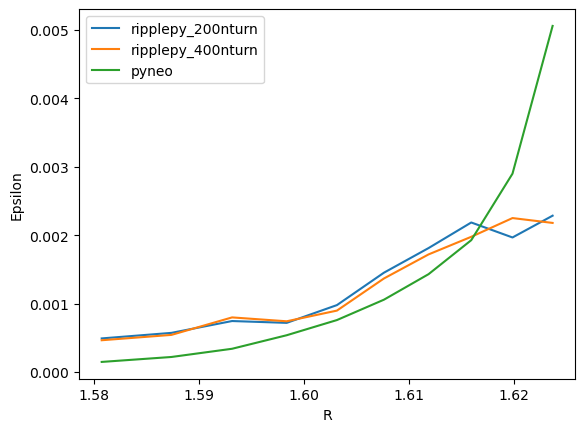

<ErrorbarContainer object of 3 artists>

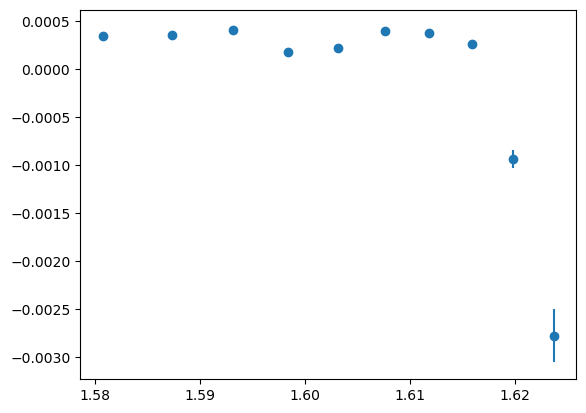

In [ ]:
ref_surfaces = RZ_points[:,0]  # 假设 RZ_points 的第一列是表面索引或半径
ripplepy_200nturn_results = np.array(ripplepy_200nturn_results)
ripplepy_400nturn_results = np.array(ripplepy_400nturn_results)

print('pyneo:', got_epstot)
print('ripplepy_200nturn:', ripplepy_200nturn_results)
print('ripplepy_400nturn:', ripplepy_400nturn_results)
print('ref_surfaces:', ref_surfaces)

plt.figure()
plt.plot(ref_surfaces, ripplepy_200nturn_results, label="ripplepy_200nturn")
plt.plot(ref_surfaces, ripplepy_400nturn_results, label="ripplepy_400nturn")
plt.plot(ref_surfaces, got_epstot, label="pyneo")
plt.xlabel("R")
plt.ylabel("Epsilon")
plt.legend()
plt.show()

# plot percentage error relative to pyneo
plt.figure()
percent_error = np.where(got_epstot != 0, (ripplepy_200nturn_results - got_epstot) / got_epstot * 100.0, np.nan)
plt.errorbar(ref_surfaces, percent_error, yerr=np.abs(percent_error) * 0.1, fmt='o', label="relative percent error vs pyneo")
plt.xlabel("R")
plt.ylabel("Percent error (%)")
plt.legend()